# PHASE 11: SHAP — Explainable AI

In [3]:
#Import Libraries
import shap
import pandas as pd
import joblib
import matplotlib.pyplot as plt

In [6]:
#Load Data and Model
X_test = pd.read_csv('../data/X_test.csv')
y_test = pd.read_csv('../data/y_test.csv').squeeze()

model = joblib.load('../models/xgboost.pkl')

In [7]:
# Create SHAP Explainer
explainer = shap.TreeExplainer(model)

In [8]:
#Calculate SHAP Values
shap_values = explainer.shap_values(X_test)

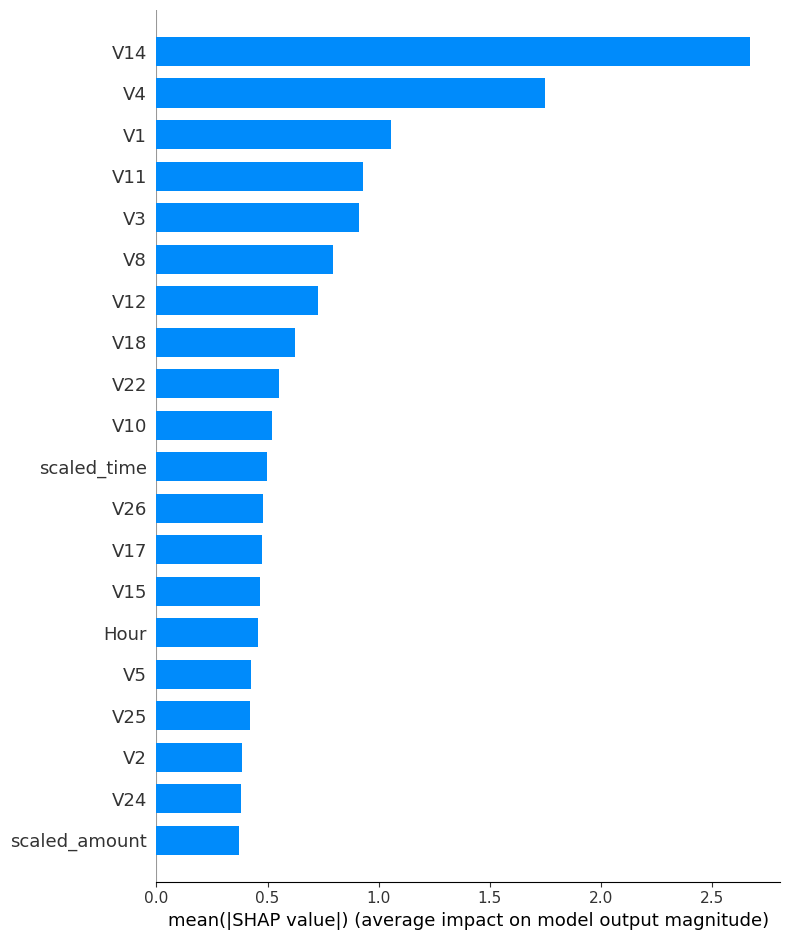

In [9]:
#Global Feature Importance
shap.summary_plot(
    shap_values,
    X_test,
    plot_type='bar'
)

In [10]:
#Save Global Importance Plot
plt.savefig(
    '../reports/11_shap_global.png',
    dpi=150
)

plt.show()

<Figure size 640x480 with 0 Axes>

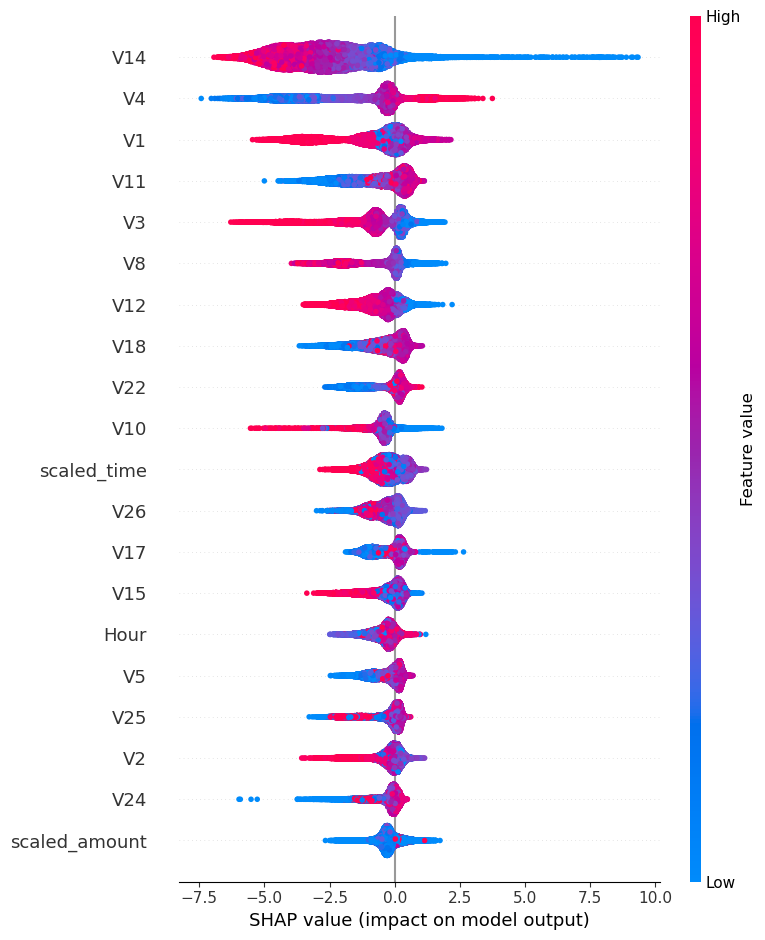

In [11]:
#SHAP Beeswarm Plot
shap.summary_plot(
    shap_values,
    X_test
)

In [12]:
#Save Beeswarm Plot
plt.savefig(
    '../reports/11_shap_beeswarm.png',
    dpi=150
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [13]:
#Find a Fraud Transaction
fraud_idx = y_test[y_test == 1].index[0]

In [14]:
#Get Its Position
test_loc = X_test.index.get_loc(fraud_idx)

In [15]:
#Print Information
print("Transaction:", fraud_idx)
print("Actual Label: FRAUD")

Transaction: 845
Actual Label: FRAUD


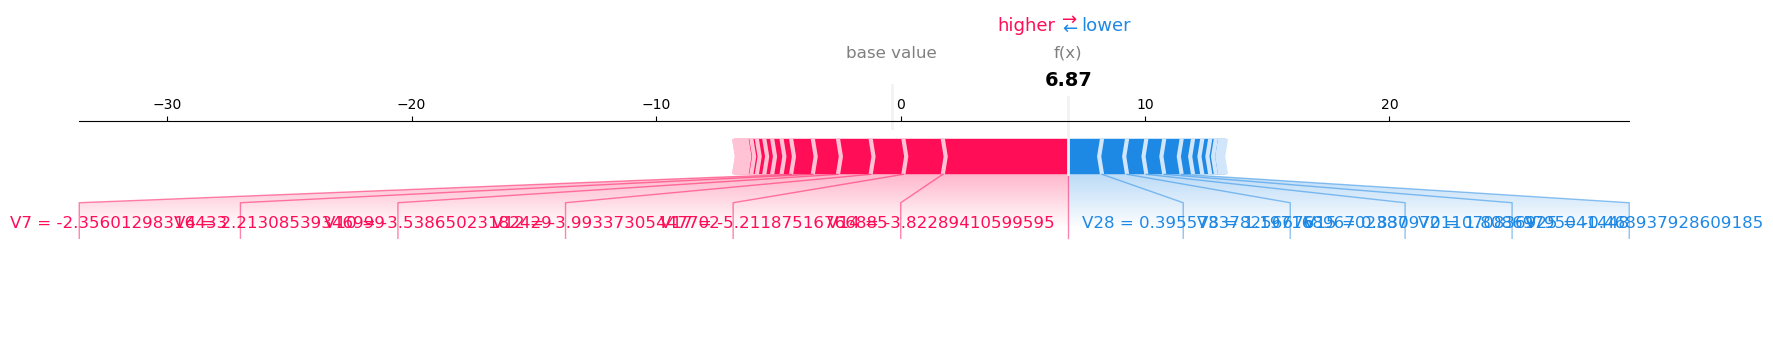

In [16]:
#Create Force Plot
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[test_loc],
    X_test.iloc[test_loc],
    matplotlib=True
)

In [17]:
#Save Local Explanation
plt.savefig(
    '../reports/11_shap_local.png',
    dpi=150
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [18]:
#Create Feature-Impact Dictionary
sample_shap = dict(
    zip(
        X_test.columns,
        shap_values[test_loc]
    )
)

In [19]:
#Sort Features by Importance
sorted_shap = sorted(
    sample_shap.items(),
    key=lambda x: abs(x[1]),
    reverse=True
)

In [20]:
#Print Top 5 Reasons
print("\nTop Fraud Reasons:")

for feat, val in sorted_shap[:5]:

    if val > 0:
        direction = "INCREASES"
    else:
        direction = "DECREASES"

    print(
        f"{feat}: {direction} fraud probability by {abs(val):.4f}"
    )


Top Fraud Reasons:
V14: INCREASES fraud probability by 5.1352
V17: INCREASES fraud probability by 1.6136
V28: DECREASES fraud probability by 1.3775
V12: INCREASES fraud probability by 1.3389
V10: INCREASES fraud probability by 1.3356
